**Importing Required Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn .preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split ,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

**Data loading and Understanding**

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# dropping the customer id column because it is not requisite
df = df.drop('customerID',axis=1)

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
# now we will see the unique value in each column and print them
for col in df.columns:
  print(f'{col} has {df[col].nunique()} unique value')
  print(df[col].unique())
  print()

gender has 2 unique value
['Female' 'Male']

SeniorCitizen has 2 unique value
[0 1]

Partner has 2 unique value
['Yes' 'No']

Dependents has 2 unique value
['No' 'Yes']

tenure has 73 unique value
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService has 2 unique value
['No' 'Yes']

MultipleLines has 3 unique value
['No phone service' 'No' 'Yes']

InternetService has 3 unique value
['DSL' 'Fiber optic' 'No']

OnlineSecurity has 3 unique value
['No' 'Yes' 'No internet service']

OnlineBackup has 3 unique value
['Yes' 'No' 'No internet service']

DeviceProtection has 3 unique value
['No' 'Yes' 'No internet service']

TechSupport has 3 unique value
['No' 'Yes' 'No internet service']

StreamingTV has 3 unique value
['No' 'Yes' 'No internet service']

StreamingMovies has 3 unique value
['No' 'Yes' 'No internet

In [ ]:
len(df[df['TotalCharges']==' '])

11

In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(' ','0.0')

In [ ]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
# Checking the distribution of target columns Churn is our target columns.
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


**Insights**


1.   Customer ID columnn has been removed because it not required for labeling .

2.   There is no missing value


1.   Missing value of total charge is replaced by 0
2.   Class imbalance identify in the target column.





# **EDA**

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# it is only work on the numerical data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Numerical feature analysis

**Understand the distribution of numerical feature**

In [ ]:
def plot_histogram(df,column_name):
  plt.figure(figsize=(10,6))
  sns.histplot(data=df,x=column_name,kde=True)
  plt.title(f'Distribution of {column_name}')
  plt.xlabel(column_name)
  plt.ylabel('Frequency')
  # calculation
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()
  # add vertical lines
  plt.axvline(col_mean,color='red',linestyle='dashed',label='mean')
  plt.axvline(col_median,color='green',linestyle='dashed',label='median')
  plt.legend()
  plt.show()

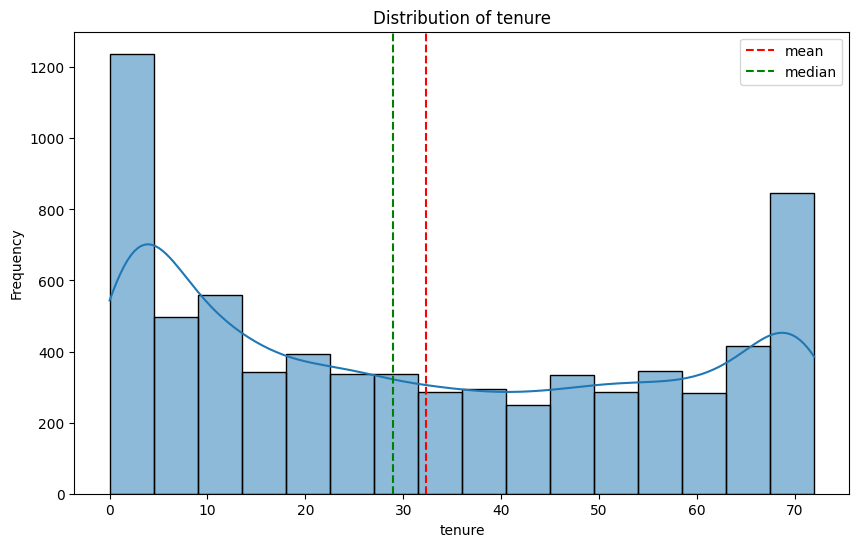

In [ ]:
plot_histogram(df,'tenure')

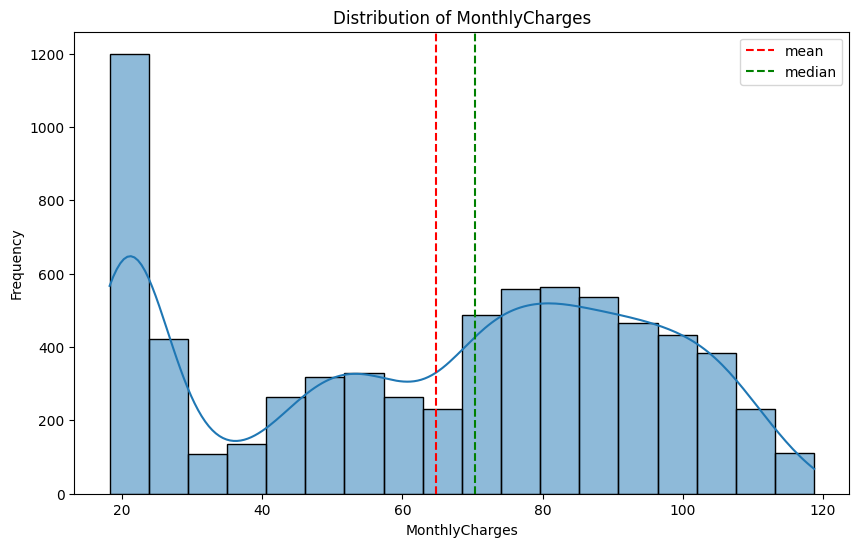

In [ ]:
plot_histogram(df,'MonthlyCharges')

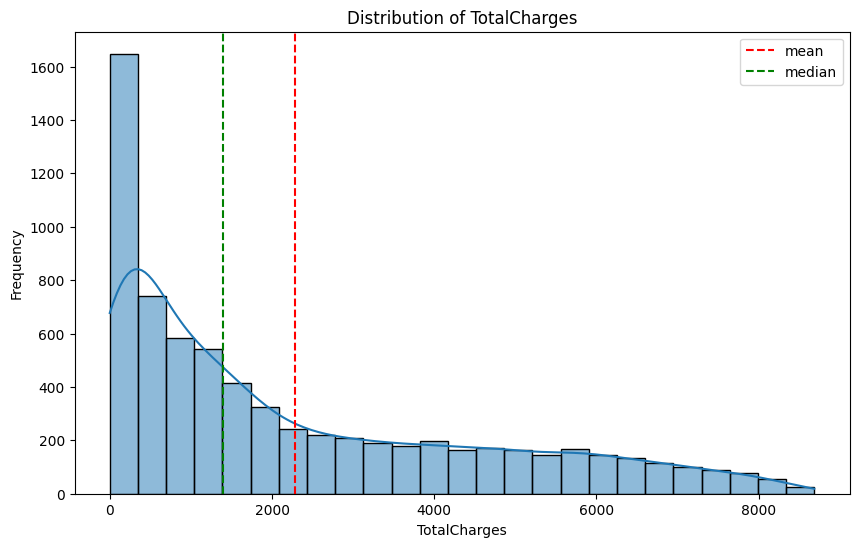

In [ ]:
plot_histogram(df,'TotalCharges')

In [ ]:
# box plot for numerical feature
def plot_boxplot(df,column_name):
  plt.figure(figsize=(7,6))
  sns.boxplot(y = df[column_name])
  plt.title(f'Distribution of {column_name}')
  plt.ylabel(column_name)
  plt.show()

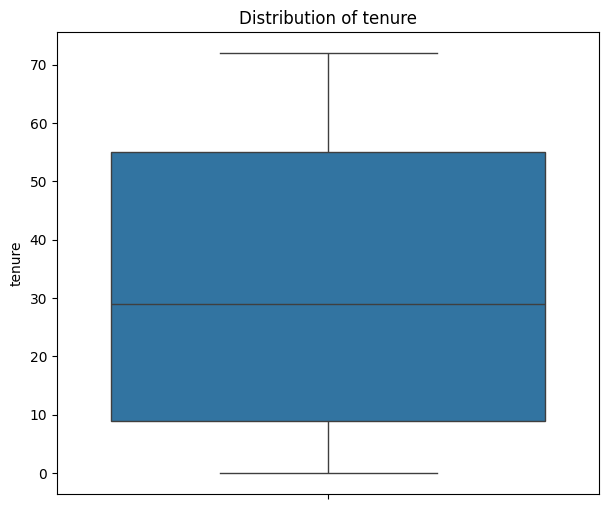

In [ ]:
plot_boxplot(df,'tenure')

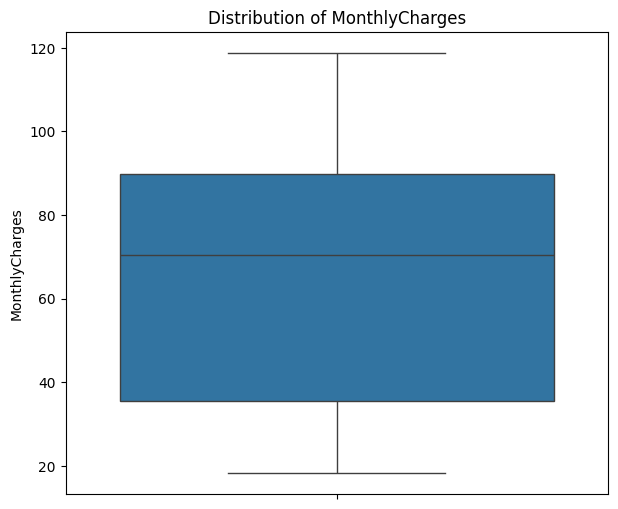

In [ ]:
plot_boxplot(df,'MonthlyCharges')

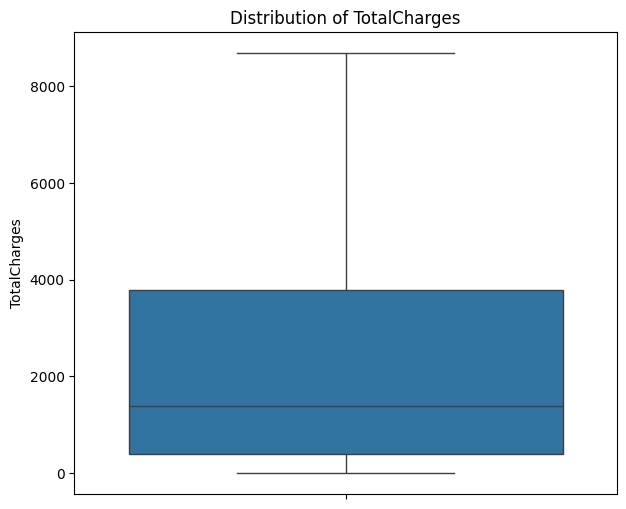

In [ ]:
plot_boxplot  (df,'TotalCharges')

# Correlation b/w numerical column

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

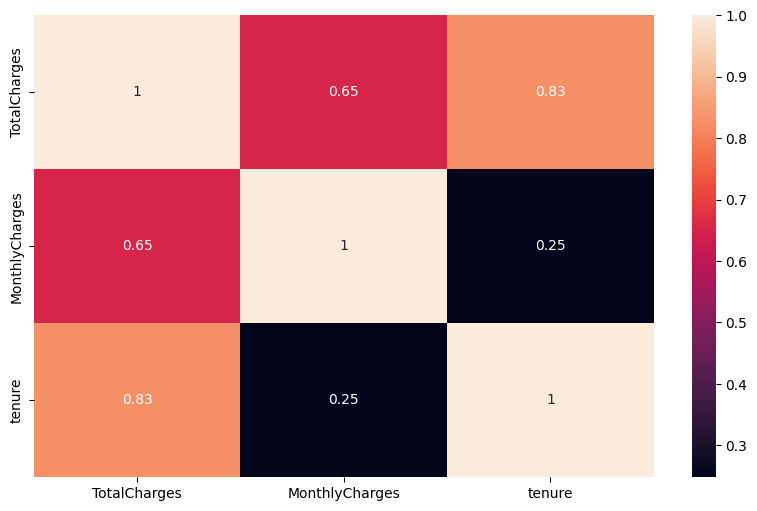

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['TotalCharges','MonthlyCharges','tenure']].corr(),annot=True)
plt.show()

# Categorical Feature analysis

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
cat_columns = df.select_dtypes(include='object').columns.to_list()

In [ ]:
cat_columns = ['SeniorCitizen'] + cat_columns

In [ ]:
cat_columns

['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

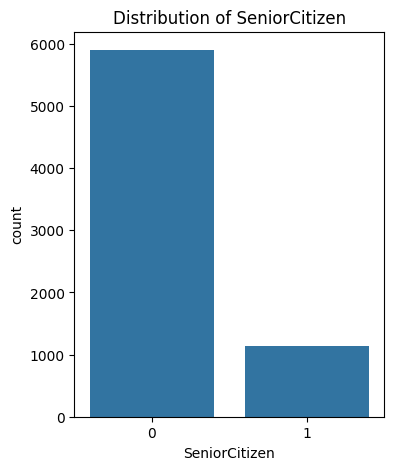

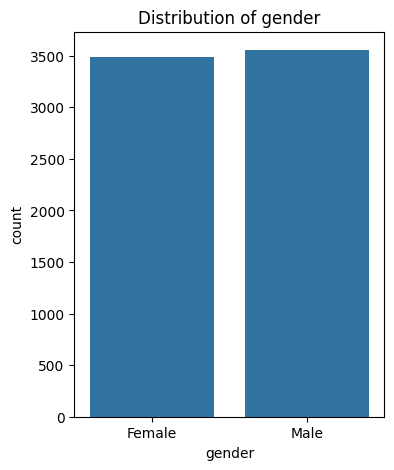

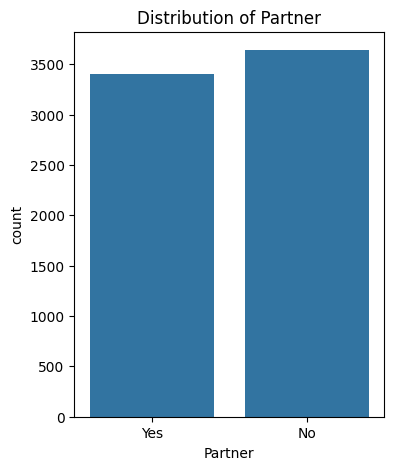

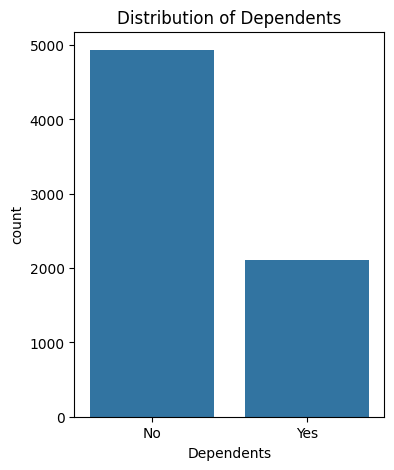

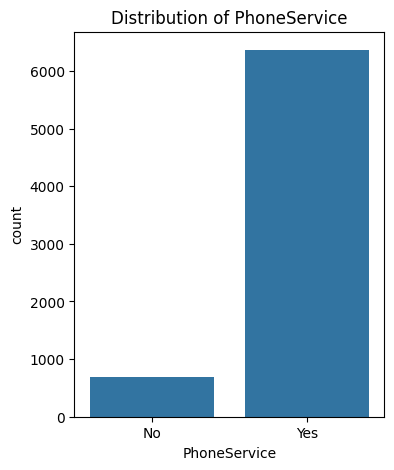

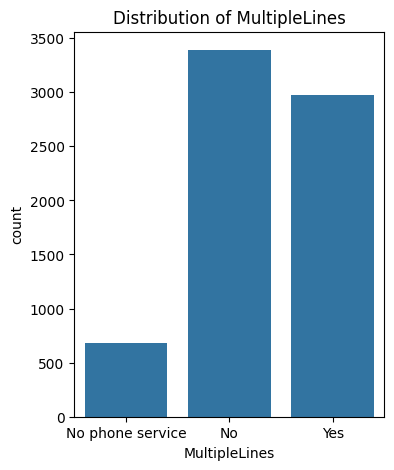

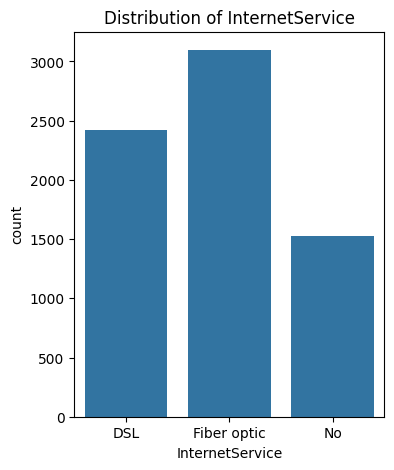

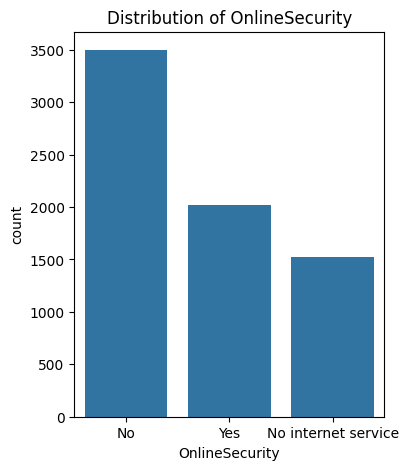

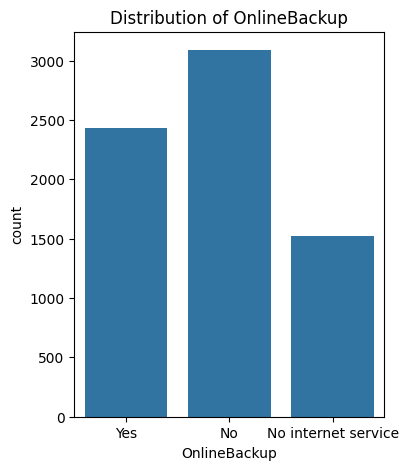

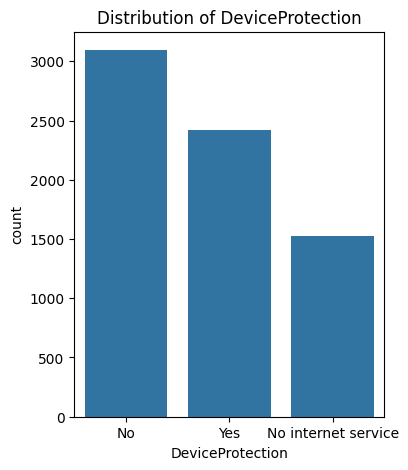

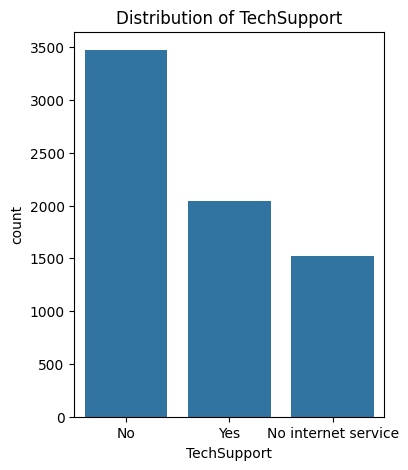

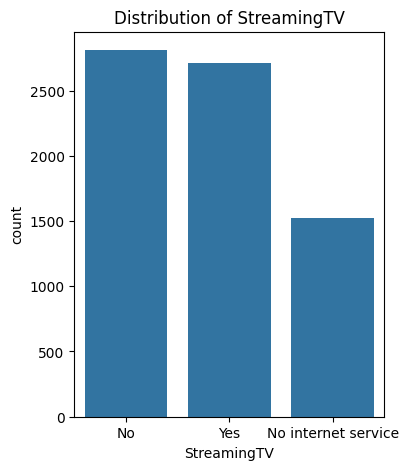

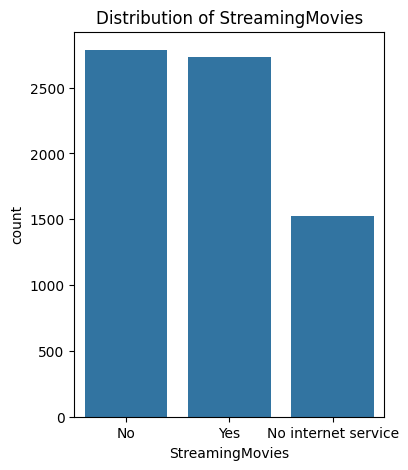

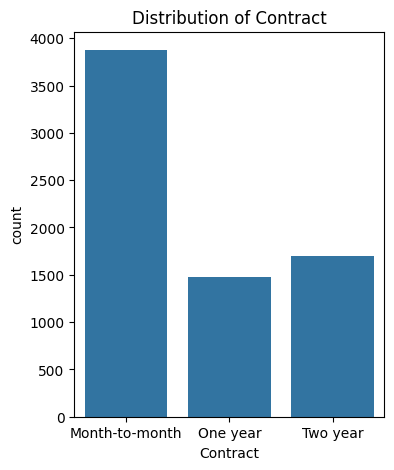

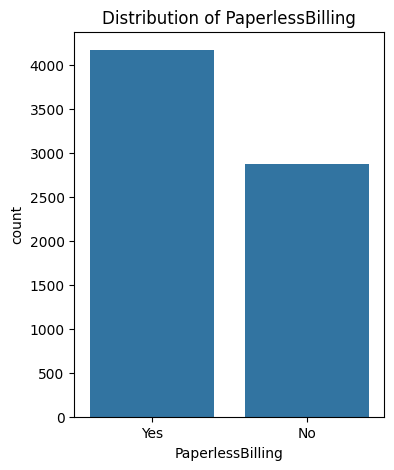

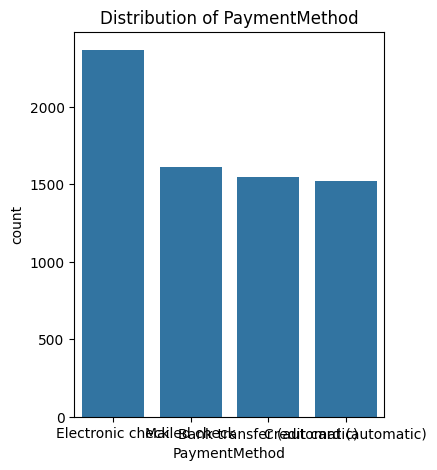

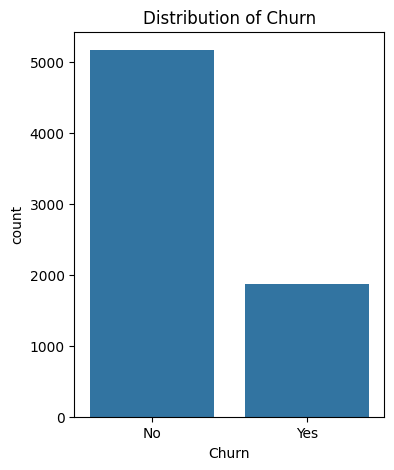

In [ ]:
for col in cat_columns:
  plt.figure(figsize=(4,5))
  sns.countplot(x=df[col])
  plt.title(f'Distribution of {col}')
  plt.show()

# **Data Preprocessing**

In [ ]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Label encoding of target column

In [ ]:
df['Churn'] = df['Churn'].replace({'Yes':1 ,'No':0})

In [ ]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
object_columns = df.select_dtypes(include='object').columns

In [ ]:
object_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [ ]:
# we will create a dict to save the encoders
encoders = {}
for col in object_columns:
  label_encoder = LabelEncoder()
  df[col] = label_encoder.fit_transform(df[col])
  encoders[col] = label_encoder

# save this encoder to pickel file
with open('encoders.pkl','wb') as file:
  pickle.dump(encoders,file)

In [ ]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [ ]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# Train and testing

In [ ]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [ ]:
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42)

In [ ]:
x_train.shape , y_train.shape

((5634, 19), (5634,))

In [ ]:
x_test.shape ,y_test.shape

((1409, 19), (1409,))

# Synthetic Minority Oversampling Technique (SMOTE)

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [ ]:
y_train_smote.value_counts()

,count
Churn,
0,4138
1,4138


# **Model Training**

In [ ]:
models = {'Decision Tree': DecisionTreeClassifier(random_state=42),
          'Random Forest': RandomForestClassifier(random_state=42),
          'Xgboost':XGBClassifier(random_state = 42)}



In [ ]:
# dict to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name,model in models.items():
  print(f'Training {model_name} model')
  cv_score = cross_val_score(model,x_train_smote,y_train_smote,cv=5)
  cv_scores[model_name] = cv_score
  print(f'{model_name} CV score: {cv_score}')
  print(f'{model_name} CV mean score: {cv_score.mean()}')
  print()

Training Decision Tree model
Decision Tree CV score: [0.68297101 0.71299094 0.82175227 0.83564955 0.83564955]
Decision Tree CV mean score: 0.7778026621130524

Training Random Forest model
Random Forest CV score: [0.72524155 0.77824773 0.90513595 0.89425982 0.90090634]
Random Forest CV mean score: 0.8407582789672636

Training Xgboost model
Xgboost CV score: [0.70048309 0.75649547 0.90271903 0.89486405 0.90030211]
Xgboost CV mean score: 0.8309727512880014



# **model Evaluation**

In [ ]:
# To fix the NotFittedError, we need to explicitly fit the model.
# The 'model' variable currently holds the XGBClassifier instance from the last iteration of the cross-validation loop.
# Let's fit this model to the entire SMOTE-resampled training data.

# We will refit the XGBoost model as it was the last one used in the cross-validation loop.
# You can choose any model from the 'models' dictionary to fit here.
# For example, to fit Random Forest:
# best_model = models['Random Forest']
# Or, to continue with XGBoost:
best_model = models['Xgboost']

best_model.fit(x_train_smote, y_train_smote)

y_test_pred = best_model.predict(x_test)

print("Accuracy Score: \n", accuracy_score(y_test,y_test_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_test_pred))
print("Classification Report: \n", classification_report(y_test,y_test_pred))

Accuracy Score: 
 0.7806955287437899
Confusion Matrix: 
 [[885 151]
 [158 215]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.59      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [ ]:
# save the trained model as a pickel file
with open('model.pkl','wb') as file:
  pickle.dump(best_model,file)

In [ ]:
input_data = {'gender': 'Female'
,'SeniorCitizen':0
,'Partner':'Yes'
,'Dependents': 'No'
,'tenure': 1
,'PhoneService' : 'No'
,'MultipleLines': 'No phone service'
,'InternetService': 'DSL'
,'OnlineSecurity': 'No'
,'OnlineBackup': 'Yes'
,'DeviceProtection': 'No'
,'TechSupport': 'No'
,'StreamingTV': 'No'
,'StreamingMovies': 'No'
,'Contract': 'Month-to-month'
,'PaperlessBilling': 'Yes'
,'PaymentMethod': 'Electronic check'
,'MonthlyCharges':29.85
,'TotalCharges':29.85
}


In [ ]:
input_data_df = pd.DataFrame([input_data])
with open('encoders.pkl','rb') as file:
  encoders = pickle.load(file)
  print(input_data_df.head())
  for column,encoder in encoders.items():
    # Ensure the column exists in input_data_df before attempting to transform
    if column in input_data_df.columns:
        input_data_df[column] = encoder.transform(input_data_df[column])

# make prediction
prediction = best_model.predict(input_data_df)
pread_prob = best_model.predict_proba(input_data_df)
print(prediction)

# result
print(f"prediction: {'Churn' if prediction[0]==1 else 'no churn'}")
print(f"Probability of Churn: {pread_prob[0][1]}")


   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   

  PaperlessBilling     PaymentMethod  MonthlyCharges  TotalCharges  
0              Yes  Electronic check           29.85         29.85  
[1]
prediction: Churn
Probability of Churn: 0.5018304586410522


In [ ]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}